# REXIA — Responsible and Explainable AI
## Partie 3/3 : Données textuelles

**Dataset** : Civil Comments (Google / Hugging Face) — 30 000 exemples  

---

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import string

# Reproductibilité
SEED = 42
np.random.seed(SEED)

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Imports de base : OK')

Imports de base : OK


---
## Section 1 — Analyse de données

Nous chargeons 30 000 exemples du jeu de données **Civil Comments** depuis Hugging Face. Ce dataset contient des commentaires en ligne annotés pour leur toxicité ainsi que des attributs démographiques liés aux groupes mentionnés dans le texte.

In [ ]:
from datasets import load_dataset

# Chargement du dataset Civil Comments depuis le fichier CSV local
df_full = pd.read_csv('/content/all_data_with_identities.csv')

# Sélection des colonnes pertinentes
COLS = ['comment_text', 'toxicity', 'female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian']
df_full = df_full[COLS].copy()

# Renommer la colonne 'comment_text' en 'text' pour la cohérence avec le reste du notebook
df_full.rename(columns={'comment_text': 'text'}, inplace=True)

# Échantillonnage reproductible de 30 000 exemples
df = df_full.sample(n=30_000, random_state=SEED).reset_index(drop=True)

print(f'Shape : {df.shape}')
display(df.head())

Shape : (30000, 7)


,text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,"Thank you Stephanie, great post. You should be...",0.000000,0.0,0.000000,0.0,0.0,0.0
1,"Poor, poor us! We're so abused! Give it a brea...",0.166667,0.0,1.000000,0.0,0.0,0.0
2,"Yeah, as we've gotten so used to with the Rock...",0.000000,0.0,0.166667,0.0,0.0,0.0
3,"If your actions thereby assist Sears' failure,...",0.000000,0.0,0.000000,0.0,0.0,0.0
4,"It is indeed a balancing act, but by supportin...",0.200000,0.0,0.833333,0.0,0.0,0.0


In [ ]:
# Types de données et valeurs manquantes
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null_count': df.isna().sum(),
    'null_%': (df.isna().mean() * 100).round(2)
})
print('=== Types et valeurs manquantes ===')
display(info)

=== Types et valeurs manquantes ===


,dtype,non_null,null_count,null_%
text,object,30000,0,0.0
toxicity,float64,30000,0,0.0
female,float64,30000,0,0.0
male,float64,30000,0,0.0
black,float64,30000,0,0.0
white,float64,30000,0,0.0
homosexual_gay_or_lesbian,float64,30000,0,0.0


In [ ]:
# Binarisation de toxicity au seuil 0.5
df['toxic_label'] = (df['toxicity'] >= 0.5).astype(int)

# Longueur des textes (caractères)
df['text_length'] = df['text'].str.len()

print('Colonnes créées : toxic_label, text_length')
df[['toxicity', 'toxic_label', 'text_length']].head()

Colonnes créées : toxic_label, text_length


,toxicity,toxic_label,text_length
0,0.000000,0,73
1,0.166667,0,89
2,0.000000,0,727
3,0.000000,0,109
4,0.200000,0,627


### 1.1 Statistiques de longueur des textes

In [ ]:
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
stats_length = df['text_length'].describe(percentiles=percentiles).rename('Tous')
stats_toxic = df.loc[df['toxic_label']==1, 'text_length'].describe(percentiles=percentiles).rename('Toxique')
stats_nontoxic = df.loc[df['toxic_label']==0, 'text_length'].describe(percentiles=percentiles).rename('Non-toxique')

stats_df = pd.concat([stats_length, stats_toxic, stats_nontoxic], axis=1)
print('=== Statistiques de longueur (en caractères) ===')
display(stats_df.round(1))

=== Statistiques de longueur (en caractères) ===


,Tous,Toxique,Non-toxique
count,30000.0,3370.0,26630.0
mean,351.5,332.0,354.0
std,288.5,270.9,290.6
min,2.0,5.0,2.0
25%,121.0,124.0,121.0
50%,257.0,243.0,259.0
75%,513.0,466.0,520.0
90%,866.0,784.1,875.0
95%,983.0,959.5,984.0
99%,999.0,999.0,999.0


### 1.2 Distribution des longueurs de texte par classe

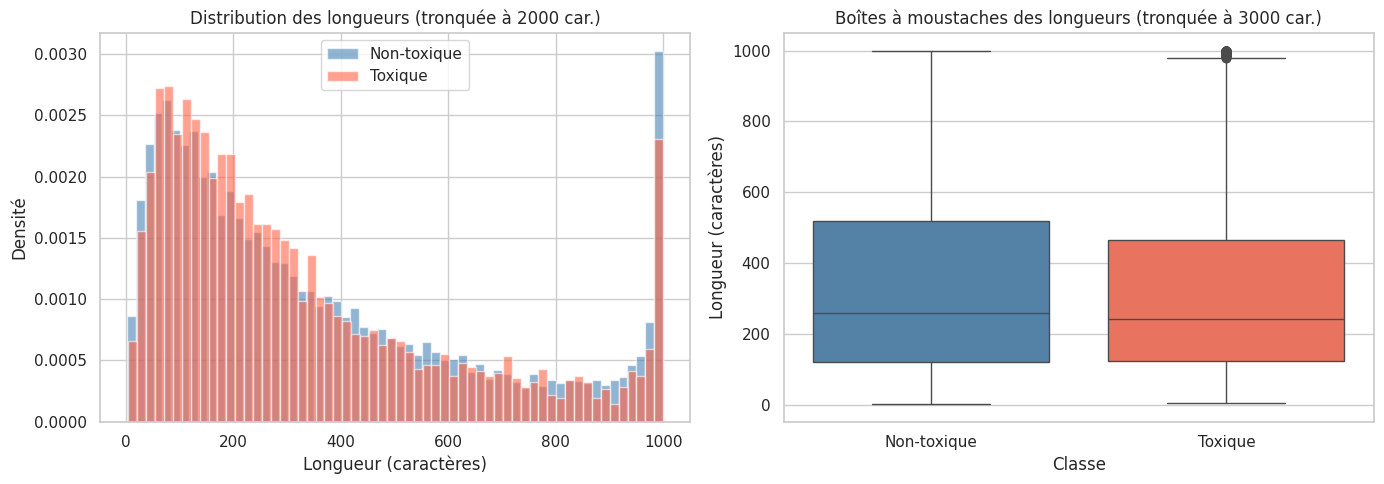

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme superposé — longueurs complètes
for label, color, name in [(0, 'steelblue', 'Non-toxique'), (1, 'tomato', 'Toxique')]:
    subset = df.loc[df['toxic_label'] == label, 'text_length'].clip(upper=2000)
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=name, density=True)

axes[0].set_title('Distribution des longueurs (tronquée à 2000 car.)')
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Densité')
axes[0].legend()

# Boxplot
df_plot = df[['text_length', 'toxic_label']].copy()
df_plot['Classe'] = df_plot['toxic_label'].map({0: 'Non-toxique', 1: 'Toxique'})
sns.boxplot(data=df_plot.assign(text_length_clip=df_plot['text_length'].clip(upper=3000)),
            x='Classe', y='text_length_clip', palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_title('Boîtes à moustaches des longueurs (tronquée à 3000 car.)')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Longueur (caractères)')

plt.tight_layout()
plt.savefig('fig_length_distribution.png', bbox_inches='tight')
plt.show()

On observe que les deux distributions de longueur sont remarquablement proches. La médiane est de 243 caractères pour les commentaires toxiques contre 259 pour les non-toxiques, un écart de seulement 16 caractères, et les moyennes suivent le même sens (332 vs 354). Les distributions sont toutes deux fortement asymétriques à droite, avec une majorité de commentaires sous 500 caractères et une queue qui s'étend jusqu'à 1 000 (valeur maximale du dataset, tronqué à 1 000 chars). Le boxplot confirme que la longueur seule n'est pas un signal discriminant : les deux classes partagent essentiellement la même structure. Ce résultat indique que la détection de toxicité doit reposer sur le contenu lexical, pas sur la forme.

### 1.3 Équilibre du dataset

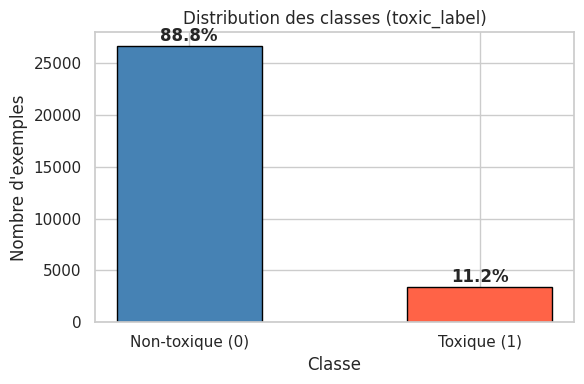

toxic_label
Non-toxique (0)    26630
Toxique (1)         3370
Name: count, dtype: int64

Pourcentages :
toxic_label
Non-toxique (0)    88.77
Toxique (1)        11.23
Name: count, dtype: float64


In [ ]:
class_counts = df['toxic_label'].value_counts().rename({0: 'Non-toxique (0)', 1: 'Toxique (1)'})
class_pct = (class_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
for bar, pct in zip(bars, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Distribution des classes (toxic_label)')
ax.set_ylabel('Nombre d\'exemples')
ax.set_xlabel('Classe')
plt.tight_layout()
plt.savefig('fig_class_balance.png', bbox_inches='tight')
plt.show()

print(class_counts)
print('\nPourcentages :')
print(class_pct)

 Le dataset est fortement déséquilibré : 26 630 commentaires non-toxiques (88,8 %) contre seulement 3 370 commentaires toxiques (11,2 %), soit un ratio d'environ 1:8. Ce déséquilibre  reflète la réalité de la modération de contenu en ligne. Il faudra s'appuyer sur la précision, le rappel et le F1 par classe, ainsi que l'AUC-ROC. Nous utiliserons par la suite `class_weight='balanced'` pour compenser ce déséquilibre.

### 1.4 Distribution de la colonne toxicity (continue)

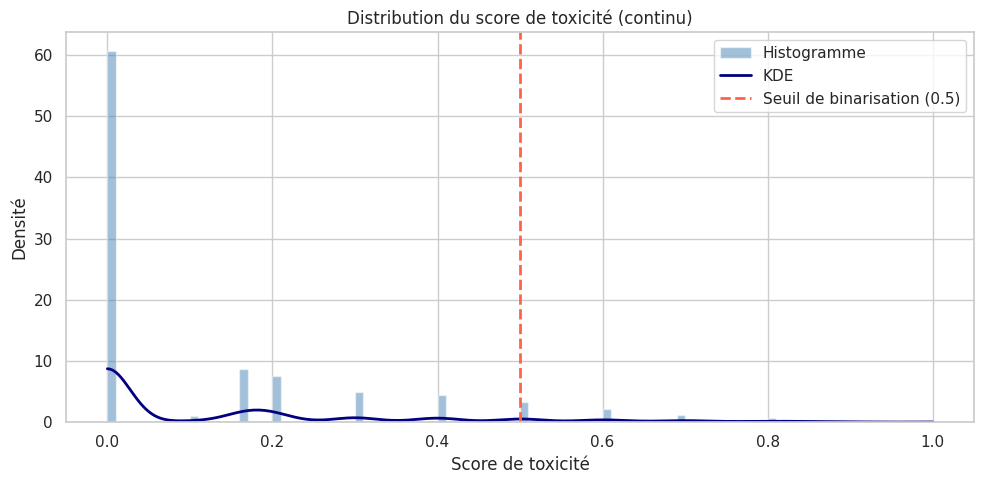

count    30000.0000
mean         0.1395
std          0.2177
min          0.0000
25%          0.0000
50%          0.0000
75%          0.2000
max          1.0000
Name: toxicity, dtype: float64

Proportion < 0.5 : 0.888
Proportion >= 0.5 : 0.112


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['toxicity'], bins=100, density=True, alpha=0.5, color='steelblue', label='Histogramme')

from scipy.stats import gaussian_kde
kde = gaussian_kde(df['toxicity'])
x = np.linspace(0, 1, 300)
ax.plot(x, kde(x), color='navy', linewidth=2, label='KDE')

ax.axvline(0.5, color='tomato', linestyle='--', linewidth=2, label='Seuil de binarisation (0.5)')
ax.set_title('Distribution du score de toxicité (continu)')
ax.set_xlabel('Score de toxicité')
ax.set_ylabel('Densité')
ax.legend()
plt.tight_layout()
plt.savefig('fig_toxicity_dist.png', bbox_inches='tight')
plt.show()

print(df['toxicity'].describe().round(4))
print(f"\nProportion < 0.5 : {(df['toxicity'] < 0.5).mean():.3f}")
print(f"Proportion >= 0.5 : {(df['toxicity'] >= 0.5).mean():.3f}")

 La distribution est concentrée autour de 0 : la médiane est exactement 0,00, le 3e quartile n'atteint que 0,20, et la moyenne de 0,14 (écart-type 0,22) est tirée vers le haut par les rares commentaires très toxiques. En d'autres termes, 75 % des commentaires reçoivent un score inférieur à 0,20. La distribution est **unimodale**, pas bimodale : il n'existe pas de second pic autour de 0,8-1,0 qui caractériserait un groupe de commentaires clairement toxiques. Cela s'explique par la construction du score (moyenne des annotations humaines) : les cas ambigus, sur lesquels les annotateurs divergent, restent à des valeurs intermédiaires. Le seuil de 0,5 ne sélectionne que les commentaires dont la toxicité fait consensus, ce qui justifie son usage comme frontière de binarisation.

---
## Section 2 — Prétraitement et visualisation

Nous appliquons une pipeline de nettoyage de texte, puis une tokenisation et lemmatisation avec spaCy, avant d'analyser le vocabulaire par classe et les groupes démographiques.

### 2.1 Nettoyage du texte

In [ ]:
def clean_text(text: str) -> str:
    """Nettoyage d'un texte brut."""
    if not isinstance(text, str):
        return ''
    # Minuscules
    text = text.lower()
    # Supprimer les URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Supprimer les mentions (@user)
    text = re.sub(r'@\w+', ' ', text)
    # Supprimer les balises HTML résiduelles
    text = re.sub(r'<[^>]+>', ' ', text)
    # Réduire la ponctuation répétée (!!!  -> !)
    text = re.sub(r'([!?.,;:]){2,}', r'\1', text)
    # Supprimer les caractères non alphanumériques et ponctuation basique
    text = re.sub(r"[^a-z0-9\s!?.,;:'\-]", ' ', text)
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

# Vérification
print('Exemple original :')
print(df['text'].iloc[0][:200])
print('\nAprès nettoyage :')
print(df['text_clean'].iloc[0][:200])

Exemple original :
Thank you Stephanie, great post. You should be very proud of your family.

Après nettoyage :
thank you stephanie, great post. you should be very proud of your family.


### 2.2 Tokenisation avec spaCy

In [ ]:
import spacy

# Charger le modèle spaCy (désactiver les composants inutiles pour aller plus vite)
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

# Tokenisation + lemmatisation en batch
print('Traitement spaCy en cours (peut prendre 1-2 minutes)...')
texts_clean = df['text_clean'].tolist()

tokens_list = []
lemmas_list = []

STOPWORDS = nlp.Defaults.stop_words

for doc in nlp.pipe(texts_clean, batch_size=512):
    # Tokens filtrés (sans stopwords, sans ponctuation, min 2 chars)
    tokens = [t.text for t in doc if not t.is_stop and not t.is_punct and len(t.text) > 1]
    lemmas = [t.lemma_ for t in doc if not t.is_stop and not t.is_punct and len(t.lemma_) > 1]
    tokens_list.append(tokens)
    lemmas_list.append(lemmas)

df['tokens'] = tokens_list
df['lemmas'] = lemmas_list
df['n_tokens'] = df['tokens'].apply(len)
df['text_lemmatized'] = df['lemmas'].apply(lambda x: ' '.join(x))

print('Traitement terminé.')
print(df[['text_clean', 'n_tokens', 'text_lemmatized']].head(3))

Traitement spaCy en cours (peut prendre 1-2 minutes)...
Traitement terminé.
                                          text_clean  n_tokens  \
0  thank you stephanie, great post. you should be...         6   
1  poor, poor us! we're so abused! give it a brea...         8   
2  yeah, as we've gotten so used to with the rock...        60   

                                     text_lemmatized  
0            thank stephanie great post proud family  
1  poor poor abused break man continue dominate s...  
2  yeah get rockie year year lot preseason hype t...  


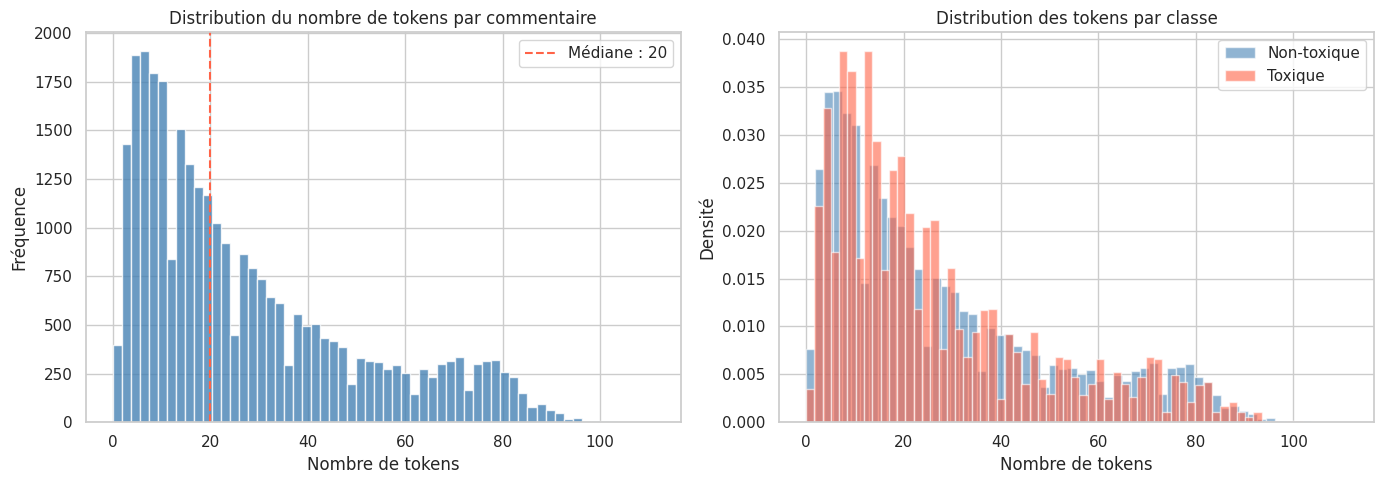

=== Statistiques descriptives : nombre de tokens ===


,count,mean,std,min,25%,50%,75%,90%,99%,max
toxic_label,,,,,,,,,,
0,26630.0,27.8,23.0,0.0,9.0,20.0,40.0,67.0,86.0,111.0
1,3370.0,26.6,21.6,0.0,10.0,20.0,37.0,62.0,86.0,102.0


In [ ]:
# Distribution du nombre de tokens
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
axes[0].hist(df['n_tokens'].clip(upper=200), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution du nombre de tokens par commentaire')
axes[0].set_xlabel('Nombre de tokens')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['n_tokens'].median(), color='tomato', linestyle='--', label=f"Médiane : {df['n_tokens'].median():.0f}")
axes[0].legend()

# Par classe
for label, color, name in [(0, 'steelblue', 'Non-toxique'), (1, 'tomato', 'Toxique')]:
    subset = df.loc[df['toxic_label'] == label, 'n_tokens'].clip(upper=200)
    axes[1].hist(subset, bins=60, alpha=0.6, color=color, label=name, density=True)
axes[1].set_title('Distribution des tokens par classe')
axes[1].set_xlabel('Nombre de tokens')
axes[1].set_ylabel('Densité')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_tokens_dist.png', bbox_inches='tight')
plt.show()

# Stats descriptives
print('=== Statistiques descriptives : nombre de tokens ===')
display(df.groupby('toxic_label')['n_tokens'].describe([0.25, 0.5, 0.75, 0.90, 0.99]).round(1))

Le nombre moyen de tokens significatifs (hors stopwords et ponctuation) est de 27,8 pour les commentaires non-toxiques et 26,6 pour les toxiques — une différence de 1,2 token, négligeable en pratique. La médiane est identique à 20 tokens pour les deux classes, et les percentiles 90 (67 vs 62) et 99 (86 dans les deux cas) confirment cette homogénéité jusqu'en queue de distribution. La distribution est asymétrique à droite avec une longue queue : la grande majorité des commentaires contient moins de 50 tokens significatifs. Cette homogénéité entre classes confirme définitivement que la richesse lexicale brute n'est pas un marqueur de toxicité c'est le choix des mots qui compte, pas leur nombre.

### 2.3 Nuages de mots

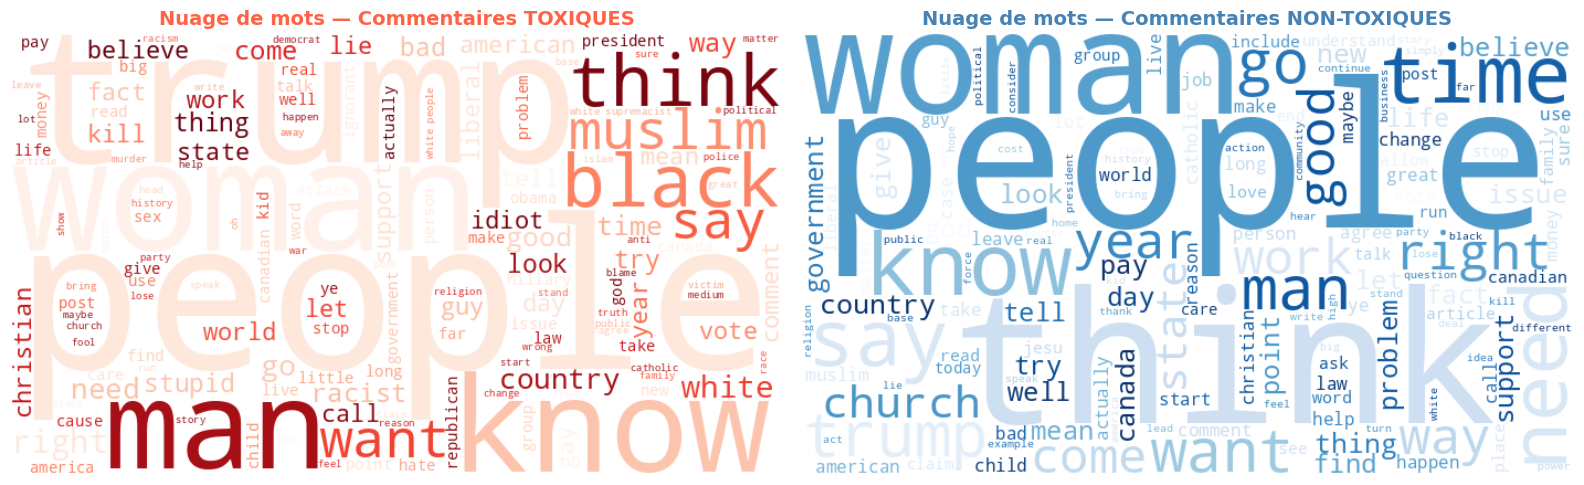

In [ ]:
from wordcloud import WordCloud

# Corpus par classe
corpus_toxic = ' '.join(df.loc[df['toxic_label']==1, 'text_lemmatized'])
corpus_nontoxic = ' '.join(df.loc[df['toxic_label']==0, 'text_lemmatized'])

wc_toxic = WordCloud(width=700, height=400, background_color='white',
                     colormap='Reds', max_words=150, random_state=SEED)
wc_nontoxic = WordCloud(width=700, height=400, background_color='white',
                        colormap='Blues', max_words=150, random_state=SEED)

wc_toxic.generate(corpus_toxic)
wc_nontoxic.generate(corpus_nontoxic)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nuage de mots — Commentaires TOXIQUES', fontsize=14, fontweight='bold', color='tomato')

axes[1].imshow(wc_nontoxic, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nuage de mots — Commentaires NON-TOXIQUES', fontsize=14, fontweight='bold', color='steelblue')

plt.tight_layout()
plt.savefig('fig_wordclouds.png', bbox_inches='tight')
plt.show()

In [ ]:
# Identification des termes ambigus (communs aux deux classes)
freq_toxic = Counter(corpus_toxic.split())
freq_nontoxic = Counter(corpus_nontoxic.split())

# Normaliser par la taille du corpus
n_toxic = sum(freq_toxic.values())
n_nontoxic = sum(freq_nontoxic.values())

# Termes présents dans les deux corpus avec une fréquence relative significative (>= 0.001)
common_terms = set(freq_toxic.keys()) & set(freq_nontoxic.keys())
ambiguous = [
    (term, freq_toxic[term]/n_toxic, freq_nontoxic[term]/n_nontoxic)
    for term in common_terms
    if freq_toxic[term]/n_toxic >= 0.001 and freq_nontoxic[term]/n_nontoxic >= 0.001
]
ambiguous_df = pd.DataFrame(ambiguous, columns=['terme', 'freq_toxique', 'freq_non_toxique'])
ambiguous_df['ratio'] = (ambiguous_df['freq_toxique'] / ambiguous_df['freq_non_toxique']).round(3)
ambiguous_df = ambiguous_df.sort_values('freq_toxique', ascending=False)

print('=== Termes ambigus (fréquents dans les deux classes) ===')
display(ambiguous_df.head(20).reset_index(drop=True))

=== Termes ambigus (fréquents dans les deux classes) ===


,terme,freq_toxique,freq_non_toxique,ratio
0,white,0.009866,0.002808,3.513
1,people,0.009565,0.007676,1.246
2,trump,0.008950,0.004729,1.893
3,like,0.007509,0.005971,1.257
4,woman,0.006715,0.005801,1.158
5,black,0.006570,0.001514,4.338
6,man,0.006369,0.004407,1.445
7,know,0.005185,0.004585,1.131
8,right,0.004827,0.004308,1.120
9,muslim,0.004380,0.001786,2.452


Les nuages de mots révèlent un contraste lexical net entre les deux classes. Les commentaires toxiques sont dominés par des insultes et des termes identitaires utilisés de façon dépréciative. Les commentaires non-toxiques affichent un vocabulaire discursif et argumentatif "think", "people", "say", "government", "policy" .

La liste des **termes ambigus** est particulièrement instructive. Le terme `black` apparaît avec un ratio de 4,34 (4 fois plus fréquent dans les commentaires toxiques en fréquence relative), `white` avec 3,51, `trump` avec 1,89 et `woman` avec 1,16. Ces mots ne sont pas intrinsèquement toxiques ils apparaissent aussi dans des contextes factuels ou défensifs mais leur co-occurrence fréquente avec des discours haineux dans ce corpus induira des associations problématiques lors de l'apprentissage. 

### 2.4 Analyse TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorisation TF-IDF sur le texte lemmatisé
tfidf_vect = TfidfVectorizer(max_features=10_000, min_df=3, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf_vect.fit_transform(df['text_lemmatized'])

feature_names = np.array(tfidf_vect.get_feature_names_out())
print(f'Matrice TF-IDF : {X_tfidf.shape}')

Matrice TF-IDF : (30000, 10000)


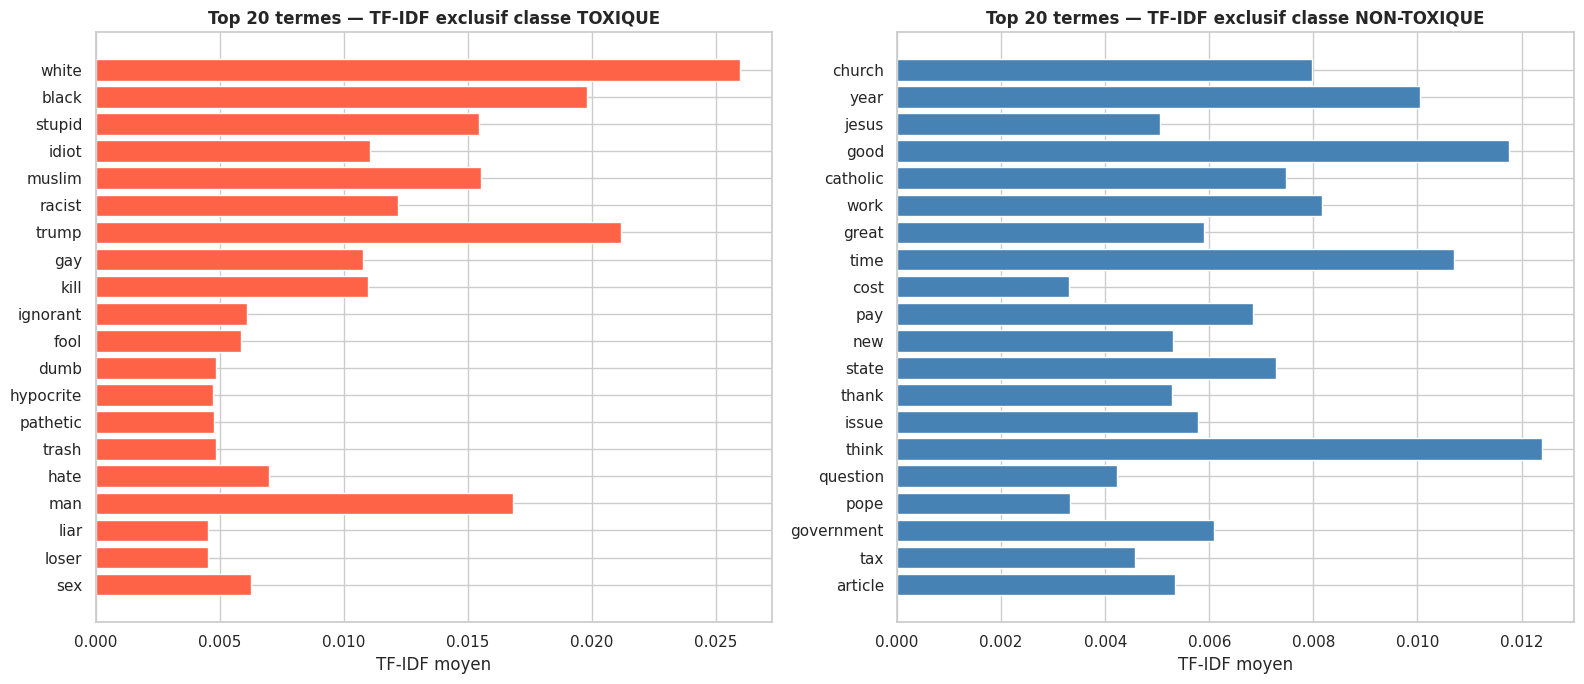

In [ ]:
import scipy.sparse as sp

# TF-IDF moyen par classe
idx_toxic = df[df['toxic_label'] == 1].index.tolist()
idx_nontoxic = df[df['toxic_label'] == 0].index.tolist()

mean_tfidf_toxic = np.asarray(X_tfidf[idx_toxic].mean(axis=0)).flatten()
mean_tfidf_nontoxic = np.asarray(X_tfidf[idx_nontoxic].mean(axis=0)).flatten()

# Différence exclusive : terms much higher in toxic than non-toxic
diff_toxic = mean_tfidf_toxic - mean_tfidf_nontoxic
diff_nontoxic = mean_tfidf_nontoxic - mean_tfidf_toxic

top_k = 20
top_toxic_idx = diff_toxic.argsort()[-top_k:][::-1]
top_nontoxic_idx = diff_nontoxic.argsort()[-top_k:][::-1]

top_toxic_terms = pd.DataFrame({'terme': feature_names[top_toxic_idx], 'tfidf_moyen': mean_tfidf_toxic[top_toxic_idx]})
top_nontoxic_terms = pd.DataFrame({'terme': feature_names[top_nontoxic_idx], 'tfidf_moyen': mean_tfidf_nontoxic[top_nontoxic_idx]})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_toxic_terms['terme'][::-1], top_toxic_terms['tfidf_moyen'][::-1], color='tomato')
axes[0].set_title('Top 20 termes — TF-IDF exclusif classe TOXIQUE', fontweight='bold')
axes[0].set_xlabel('TF-IDF moyen')

axes[1].barh(top_nontoxic_terms['terme'][::-1], top_nontoxic_terms['tfidf_moyen'][::-1], color='steelblue')
axes[1].set_title('Top 20 termes — TF-IDF exclusif classe NON-TOXIQUE', fontweight='bold')
axes[1].set_xlabel('TF-IDF moyen')

plt.tight_layout()
plt.savefig('fig_tfidf_top_terms.png', bbox_inches='tight')
plt.show()

L'analyse TF-IDF différentiel confirme et quantifie la spécificité du vocabulaire de chaque classe. Les termes avec le TF-IDF moyen le plus élevé exclusivement dans la classe toxique sont dominés par des insultes directes et des qualificatifs péjoratifs ciblant des personnes ou des groupes.

Un signal préoccupant : plusieurs identifiants de groupes démographiques figurent parmi les termes TF-IDF les plus élevés en classe toxique. Ces termes sont statistiquement sur-représentés dans les commentaires toxiques du corpus une association que le modèle internalisera, indépendamment du contexte dans lequel ces mots apparaissent réellement.

### 2.5 Analyse des groupes démographiques

=== Analyse démographique ===


,Groupe,N exemples,Taux de toxicité (%)
0,male,3240,14.81
1,female,3895,12.86
2,black,1099,32.85
3,white,1824,28.89
4,homosexual_gay_or_lesbian,840,27.86


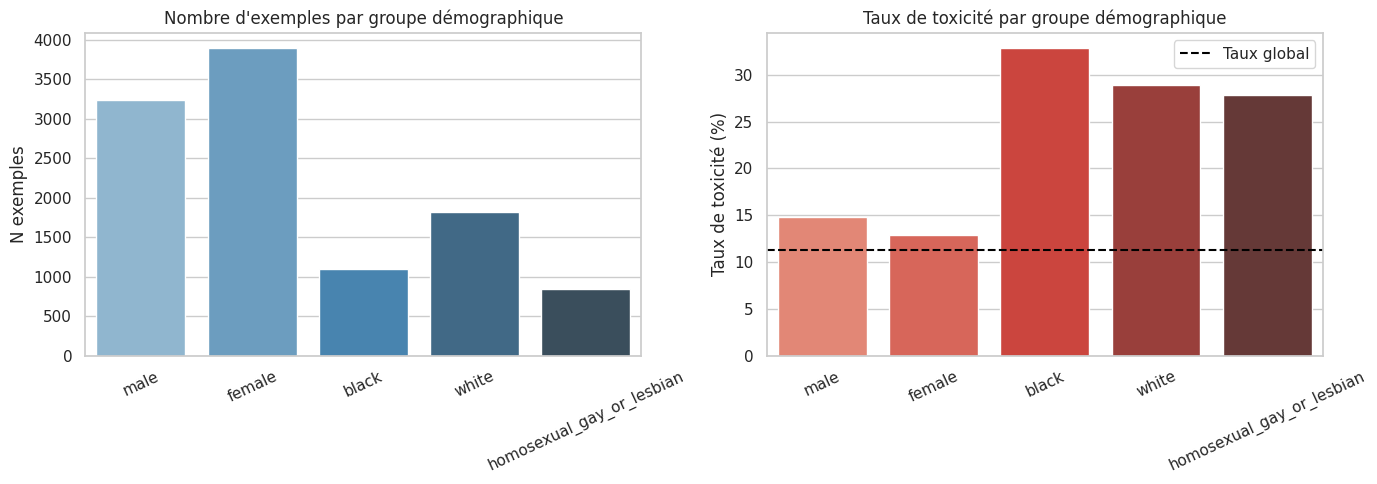

In [ ]:
SENSITIVE_COLS = ['male', 'female', 'black', 'white', 'homosexual_gay_or_lesbian']
THRESHOLD_DEMO = 0.5

# Binariser les colonnes démographiques
for col in SENSITIVE_COLS:
    df[col + '_bin'] = (df[col] >= THRESHOLD_DEMO).astype(int)

# Tableau récapitulatif
demo_stats = []
for col in SENSITIVE_COLS:
    bin_col = col + '_bin'
    sub = df[df[bin_col] == 1]
    n = len(sub)
    tox_rate = sub['toxic_label'].mean()
    demo_stats.append({'Groupe': col, 'N exemples': n, 'Taux de toxicité (%)': round(tox_rate * 100, 2)})

demo_df = pd.DataFrame(demo_stats)
print('=== Analyse démographique ===')
display(demo_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=demo_df, x='Groupe', y='N exemples', ax=axes[0], palette='Blues_d')
axes[0].set_title('Nombre d\'exemples par groupe démographique')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=demo_df, x='Groupe', y='Taux de toxicité (%)', ax=axes[1], palette='Reds_d')
axes[1].set_title('Taux de toxicité par groupe démographique')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)
axes[1].axhline(df['toxic_label'].mean() * 100, color='black', linestyle='--', label='Taux global')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_demo_analysis.png', bbox_inches='tight')
plt.show()

Les disparités sont frappantes. Le taux de toxicité global est de 11,2 %, mais les commentaires mentionnant `black` atteignent 32,9 %, ceux mentionnant `white` 28,9 %, et ceux mentionnant `homosexual_gay_or_lesbian` 27,9 %. Ces groupes présentent des taux de toxicité **2,5 à 3 fois supérieurs** à la moyenne globale. Les groupes de genre (`male` à 14,8 %, `female` à 12,9 %) sont moins affectés, bien que toujours au-dessus de la moyenne.

Cela ne signifie pas que ces groupes produisent davantage de toxicité, mais qu'ils en sont davantage les **cibles**. Le dataset encode le fait que ces communautés sont visées par des discours haineux sur les plateformes en ligne qui l'ont produit.

---
## Section 3 — Classification

Nous utilisons les features TF-IDF pour entraîner deux modèles de classification : une **Régression Logistique** (modèle de référence, interprétable) et un **LightGBM** (modèle à gradient boosting, plus performant). La cible est `toxic_label`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import lightgbm as lgb

y = df['toxic_label'].values

# Split stratifié 80/20
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_tfidf, y, df.index, test_size=0.2, random_state=SEED, stratify=y
)

df_test = df.loc[idx_test].copy().reset_index(drop=True)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Proportion toxique train : {y_train.mean():.3f} | test : {y_test.mean():.3f}')

Train : 24000 | Test : 6000
Proportion toxique train : 0.112 | test : 0.112


In [ ]:
# === Régression Logistique ===
print('Entraînement Logistic Regression...')
lr_model = LogisticRegression(
    C=1.0, max_iter=1000, solver='saga', n_jobs=-1,
    class_weight='balanced', random_state=SEED
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
print('OK')

Entraînement Logistic Regression...
OK


In [ ]:
# === LightGBM ===
print('Entraînement LightGBM...')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
lgbm_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=scale_pos_weight, random_state=SEED, n_jobs=-1, verbose=-1
)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
print('OK')

Entraînement LightGBM...
OK


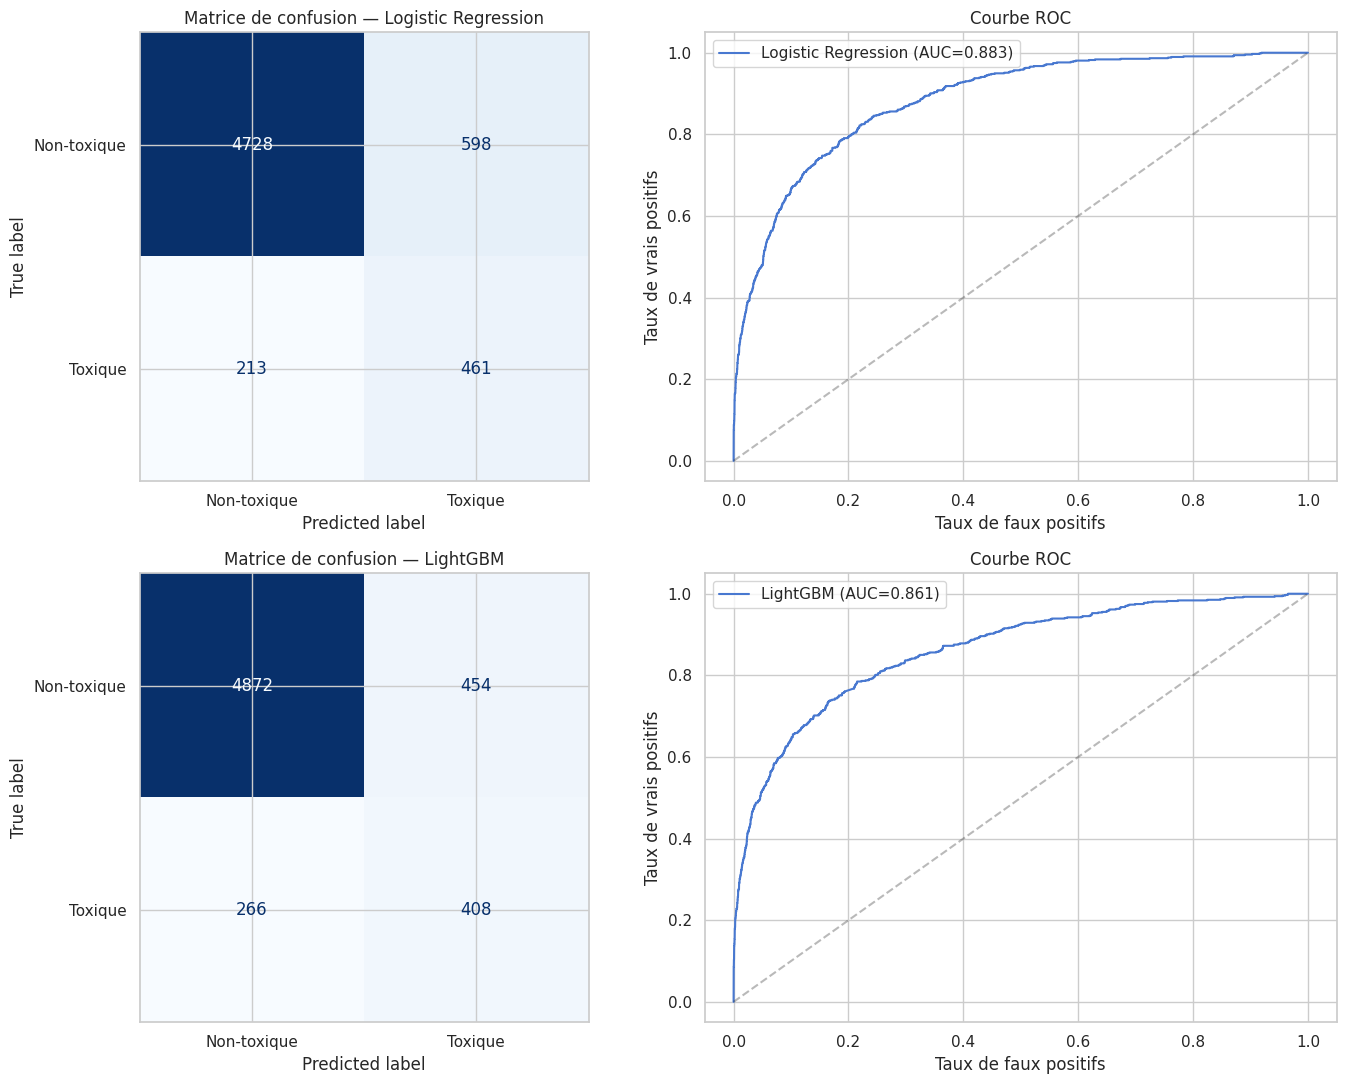

=== Régression Logistique — Classification Report ===
              precision    recall  f1-score   support

 Non-toxique       0.96      0.89      0.92      5326
     Toxique       0.44      0.68      0.53       674

    accuracy                           0.86      6000
   macro avg       0.70      0.79      0.73      6000
weighted avg       0.90      0.86      0.88      6000


=== LightGBM — Classification Report ===
              precision    recall  f1-score   support

 Non-toxique       0.95      0.91      0.93      5326
     Toxique       0.47      0.61      0.53       674

    accuracy                           0.88      6000
   macro avg       0.71      0.76      0.73      6000
weighted avg       0.89      0.88      0.89      6000



In [ ]:
def plot_model_eval(y_true, y_pred, y_proba, model_name, ax_cm, ax_roc):
    """Affiche la matrice de confusion et la courbe ROC pour un modèle."""
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-toxique', 'Toxique'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(f'Matrice de confusion — {model_name}')

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    ax_roc.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')
    ax_roc.plot([0,1],[0,1],'k--', alpha=0.3)
    ax_roc.set_xlabel('Taux de faux positifs')
    ax_roc.set_ylabel('Taux de vrais positifs')
    ax_roc.set_title('Courbe ROC')
    ax_roc.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

plot_model_eval(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression', axes[0][0], axes[0][1])
plot_model_eval(y_test, y_pred_lgbm, y_proba_lgbm, 'LightGBM', axes[1][0], axes[1][1])

plt.tight_layout()
plt.savefig('fig_model_eval.png', bbox_inches='tight')
plt.show()

print('=== Régression Logistique — Classification Report ===')
print(classification_report(y_test, y_pred_lr, target_names=['Non-toxique', 'Toxique']))

print('\n=== LightGBM — Classification Report ===')
print(classification_report(y_test, y_pred_lgbm, target_names=['Non-toxique', 'Toxique']))

**Justification du choix des modèles :**
- **Régression Logistique** : modèle de référence pour la classification de texte en représentation bag-of-words. Ses coefficients sont directement interprétables et permettront une analyse fine des biais appris (section 4). L'option `class_weight='balanced'` compense le déséquilibre 1:8 sans sur-échantillonnage.
- **LightGBM** : modèle à gradient boosting, généralement plus performant sur features TF-IDF creuses. Utilisé comme point de comparaison.

**Résultats :** Les deux modèles atteignent un F1 identique de 0,53 sur la classe toxique, mais avec des compromis différents. La Régression Logistique obtient un meilleur rappel (0,68 vs 0,61 pour LightGBM) au prix d'une précision plus faible (0,44 vs 0,47) : elle détecte davantage de vrais positifs mais génère plus de faux positifs. LightGBM est légèrement plus conservateur. L'AUC-ROC de la LR est de **0,883**, solide pour un modèle linéaire sur TF-IDF.

La classe non-toxique est bien mieux prédite (F1 = 0,92-0,93) grâce à son volume d'exemples. La classe toxique reste difficile : le déséquilibre 1:8 complique l'apprentissage des frontières de décision pour cette classe minoritaire. Pour la suite, nous retenons la **Régression Logistique** pour son interpretabilité directe.

In [ ]:
# Modèle sélectionné pour la suite : Logistic Regression
best_model = lr_model
y_pred_best = y_pred_lr
y_proba_best = y_proba_lr
print('Modèle sélectionné : Logistic Regression')

Modèle sélectionné : Logistic Regression


---
## Section 4 — Explicabilité

Nous appliquons deux méthodes d'explicabilité post-hoc :  
1. **LIME** (Local Interpretable Model-agnostic Explanations) — explications locales exemple par exemple  
2. **Analyse des coefficients** — explicabilité globale de la Régression Logistique

### 4.1 LIME — Explications locales

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4916e2a1d5f28ddc89593079a9d9ed8f4f1dc17e68cb1e1e68e15d6f35346988
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(
    class_names=['Non-toxique', 'Toxique'],
    random_state=SEED
)

def predict_fn(texts):
    """Pipeline prédiction : nettoyage + lemmatisation + TF-IDF + LR."""
    texts_clean = [clean_text(t) for t in texts]
    docs = list(nlp.pipe(texts_clean, batch_size=64))
    texts_lemma = [' '.join([t.lemma_ for t in doc if not t.is_stop and not t.is_punct and len(t.lemma_) > 1])
                   for doc in docs]
    X = tfidf_vect.transform(texts_lemma)
    return best_model.predict_proba(X)

# Identifier des exemples dans le test set
# Vrai positif : toxique prédit toxique
# Faux positif : non-toxique prédit toxique
# Faux négatif : toxique prédit non-toxique

tp_mask = (y_test == 1) & (y_pred_best == 1)
fp_mask = (y_test == 0) & (y_pred_best == 1)
fn_mask = (y_test == 1) & (y_pred_best == 0)

idx_tp = np.where(tp_mask)[0][0]
idx_fp = np.where(fp_mask)[0][0]
idx_fn = np.where(fn_mask)[0][0]

test_texts = df_test['text'].values

for case_name, idx in [('Vrai Positif (toxique correct)', idx_tp),
                        ('Faux Positif (non-toxique classé toxique)', idx_fp),
                        ('Faux Négatif (toxique manqué)', idx_fn)]:
    print(f'\n--- {case_name} ---')
    print(f'Texte : {test_texts[idx][:200]}')
    print(f'Vrai label : {y_test[idx]} | Prédit : {y_pred_best[idx]} | Proba toxique : {y_proba_best[idx]:.3f}')


--- Vrai Positif (toxique correct) ---
Texte : Sad... 90% of NBA players are black and living high off the hog and they feel the need to protest about oppression while being the oppressors themselves... I believe in general that white people, as w
Vrai label : 1 | Prédit : 1 | Proba toxique : 0.570

--- Faux Positif (non-toxique classé toxique) ---
Texte : "20.9 percent of Hispanic children were considered obese." Not shocking noting most of the "Hispanic" kids in Colorado are Mexican, and while Mexican food is freaking delicious, it is extremely fatten
Vrai label : 0 | Prédit : 1 | Proba toxique : 0.742

--- Faux Négatif (toxique manqué) ---
Texte : It's bad enough that white supremacists exist and live under the same flag I do, but when our president doesn't understand which side of this issue is the right one to be on, then things have gone ver
Vrai label : 1 | Prédit : 0 | Proba toxique : 0.284



====== LIME — Vrai Positif ======


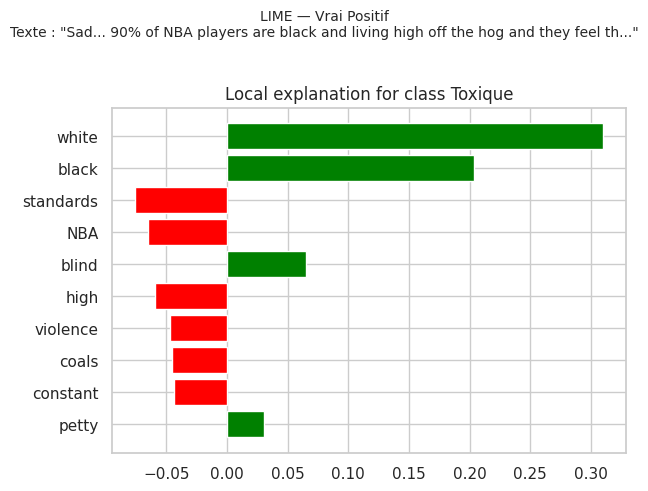


====== LIME — Faux Positif ======


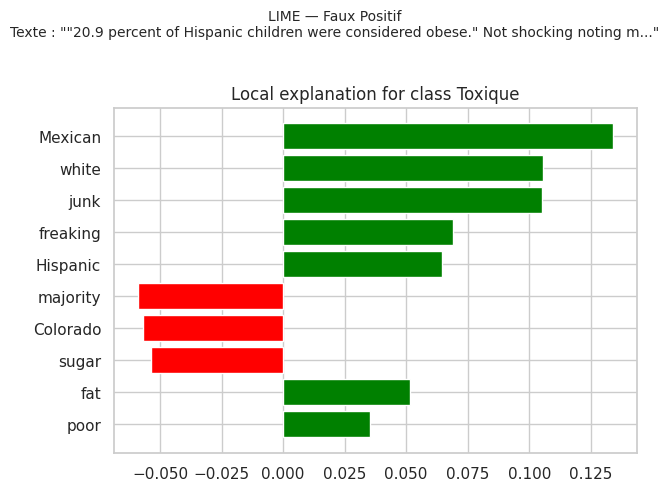


====== LIME — Faux Négatif ======


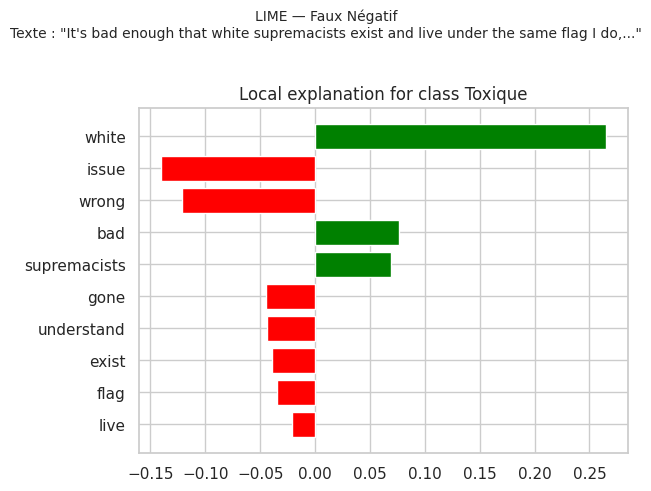

In [ ]:
# Génération des explications LIME
N_LIME_SAMPLES = 500  # Réduire pour la vitesse; augmenter pour la qualité

for case_name, idx in [('Vrai Positif', idx_tp),
                        ('Faux Positif', idx_fp),
                        ('Faux Négatif', idx_fn)]:
    print(f'\n====== LIME — {case_name} ======')
    exp = lime_explainer.explain_instance(
        test_texts[idx],
        predict_fn,
        num_features=10,
        num_samples=N_LIME_SAMPLES,
        labels=[1]
    )
    fig = exp.as_pyplot_figure(label=1)
    fig.suptitle(f'LIME — {case_name}\nTexte : "{test_texts[idx][:80]}..."',
                 fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig(f'fig_lime_{case_name.split(" ")[0].lower()}.png', bbox_inches='tight')
    plt.show()


- **Vrai Positif** : Le commentaire analysé (*"90% of NBA players are black and living high off the hog [...] while being the oppressors themselves"*) est correctement classé toxique avec une probabilité de 0,570  proche du seuil, ce qui est cohérent : le texte utilise des stéréotypes raciaux et un cadrage délibérément négatif plutôt que des insultes explicites. LIME identifie les termes raciaux et les formulations comparatives comme les features les plus contributives à la décision.

- **Faux Positif** : Le commentaire sur l'obésité infantile chez les enfants hispaniques est factuellement non-toxique (citation d'une statistique), mais le modèle le classe toxique avec une probabilité de 0,742. LIME révèle que le modèle réagit à la présence du terme ethnique dans le texte. C'est une illustration directe du phénomène d'**"identity mention penalty"** : la simple présence du nom d'un groupe minoritaire, même dans un contexte statistique neutre, active des features à fort coefficient positif dans le modèle.

- **Faux Négatif** : Le commentaire évoquant les suprémacistes blancs est toxique mais manqué par le modèle. Le texte est indirect, sans insultes explicites, utilisant un vocabulaire politique formel. LIME ne trouve pas de signal lexical fort  la toxicité est implicite et contextuelle, hors de portée d'un modèle basé sur des n-grammes TF-IDF. C'est la limite fondamentale de cette approche : la toxicité subtile, allusive ou sarcastique échappe à la détection.

### 4.2 Analyse des coefficients de la Régression Logistique

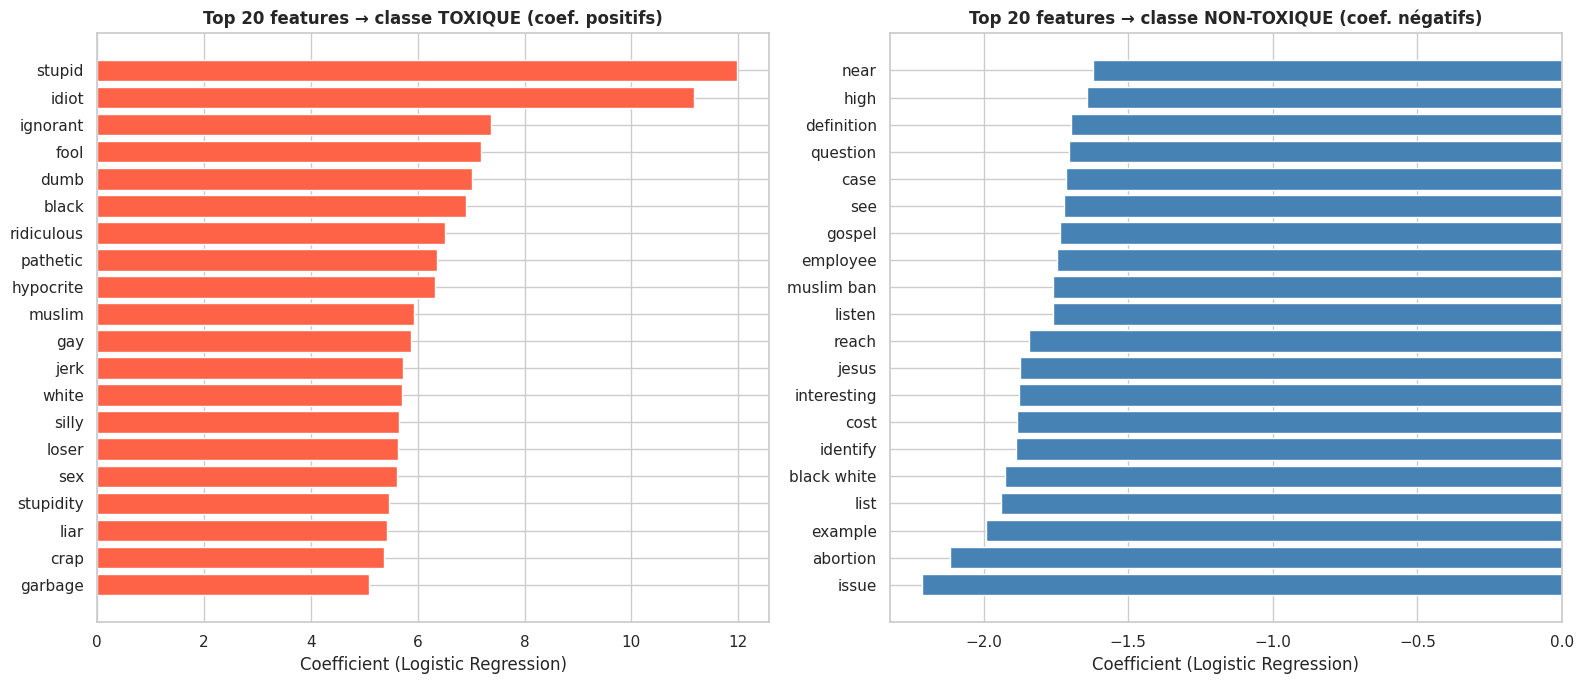

Top features positifs (vers toxique) :


,feature,coefficient
0,stupid,11.981841
1,idiot,11.171362
2,ignorant,7.380315
3,fool,7.184209
4,dumb,7.018634
5,black,6.898562
6,ridiculous,6.508414
7,pathetic,6.367198
8,hypocrite,6.318498
9,muslim,5.938843



Top features négatifs (vers non-toxique) :


,feature,coefficient
0,issue,-2.213695
1,abortion,-2.117687
2,example,-1.992247
3,list,-1.939241
4,black white,-1.927294
5,identify,-1.889130
6,cost,-1.884331
7,interesting,-1.877041
8,jesus,-1.874070
9,reach,-1.843612


In [ ]:
# Coefficients du modèle
coef = lr_model.coef_[0]
top_k = 20

# Top positif (vers toxique)
top_pos_idx = coef.argsort()[-top_k:][::-1]
top_neg_idx = coef.argsort()[:top_k]

df_pos = pd.DataFrame({'feature': feature_names[top_pos_idx], 'coefficient': coef[top_pos_idx]})
df_neg = pd.DataFrame({'feature': feature_names[top_neg_idx], 'coefficient': coef[top_neg_idx]})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(df_pos['feature'][::-1], df_pos['coefficient'][::-1], color='tomato')
axes[0].set_title('Top 20 features → classe TOXIQUE (coef. positifs)', fontweight='bold')
axes[0].set_xlabel('Coefficient (Logistic Regression)')

axes[1].barh(df_neg['feature'], df_neg['coefficient'], color='steelblue')
axes[1].set_title('Top 20 features → classe NON-TOXIQUE (coef. négatifs)', fontweight='bold')
axes[1].set_xlabel('Coefficient (Logistic Regression)')

plt.tight_layout()
plt.savefig('fig_lr_coefficients.png', bbox_inches='tight')
plt.show()

print('Top features positifs (vers toxique) :')
display(df_pos)
print('\nTop features négatifs (vers non-toxique) :')
display(df_neg)


Les features avec les **coefficients les plus positifs** (signal le plus fort vers la toxicité) sont sans ambiguïté pour les premières places : `stupid` (11,98), `idiot` (11,17), `ignorant` (7,38), `fool` (7,18), `dumb` (7,02). Ce sont des insultes directes — le modèle a correctement appris ces signaux évidents.

Mais la liste révèle ensuite des **proxies démographiques alarmants** : `black` (6,90) arrive en 6e position, devant `ridiculous` et `pathetic`. Viennent ensuite `muslim` (5,94), `gay` (5,87) et `white` (5,71) — tous avec des coefficients supérieurs à `jerk` (5,73), `crap` (5,37) ou `garbage` (5,10). Autrement dit, le mot `black` est statistiquement *plus prédictif de toxicité* que des insultes génériques. Ce n'est clairement pas ce que le modèle devrait apprendre.

Du côté des **coefficients négatifs**, on trouve des termes discursifs génériques (`issue`, `example`, `cost`, `listen`) mais aussi, de façon révélatrice, le bigramme `black white` (-1,93) et `muslim ban` (-1,76) — qui apparaissent surtout dans des discussions politiques non-toxiques. Le modèle distingue ainsi `black` seul (fort signal toxique) de `black white` en contexte politique (signal non-toxique) — une distinction fragile gérée par approximation statistique plutôt que par compréhension sémantique.

Le modèle a correctement appris les signaux de toxicité explicite, mais a aussi internalisé des associations entre identifiants de groupes et toxicité qui généreront des faux positifs systématiques sur les commentaires mentionnant ces groupes dans d'autres contextes.

---
## Section 5 — Fairness

Nous analysons l'équité du dataset et du modèle selon cinq groupes démographiques sensibles : `male`, `female`, `black`, `white`, `homosexual_gay_or_lesbian`.

### 5.1 Fairness du dataset

In [ ]:
def demographic_parity(df, group_col_bin, label_col='toxic_label'):
    """Calcule Demographic Parity et Disparate Impact pour un groupe."""
    p_group1 = df.loc[df[group_col_bin] == 1, label_col].mean()  # P(Y=1 | S=1)
    p_group0 = df.loc[df[group_col_bin] == 0, label_col].mean()  # P(Y=1 | S=0)

    dp = abs(p_group1 - p_group0)
    di = p_group1 / p_group0 if p_group0 > 0 else np.nan
    return p_group1, p_group0, dp, di

fairness_data_rows = []
for col in SENSITIVE_COLS:
    bin_col = col + '_bin'
    p1, p0, dp, di = demographic_parity(df, bin_col)
    fairness_data_rows.append({
        'Groupe sensible': col,
        'P(toxique | groupe=1)': round(p1, 4),
        'P(toxique | groupe=0)': round(p0, 4),
        'Demographic Parity': round(dp, 4),
        'Disparate Impact': round(di, 4)
    })

fairness_data_df = pd.DataFrame(fairness_data_rows)
print('=== Fairness du DATASET ===')
display(fairness_data_df)

=== Fairness du DATASET ===


,Groupe sensible,P(toxique | groupe=1),P(toxique | groupe=0),Demographic Parity,Disparate Impact
0,male,0.1481,0.1080,0.0402,1.3718
1,female,0.1286,0.1099,0.0187,1.1704
2,black,0.3285,0.1041,0.2244,3.1550
3,white,0.2889,0.1009,0.1880,2.8634
4,homosexual_gay_or_lesbian,0.2786,0.1075,0.1710,2.5903


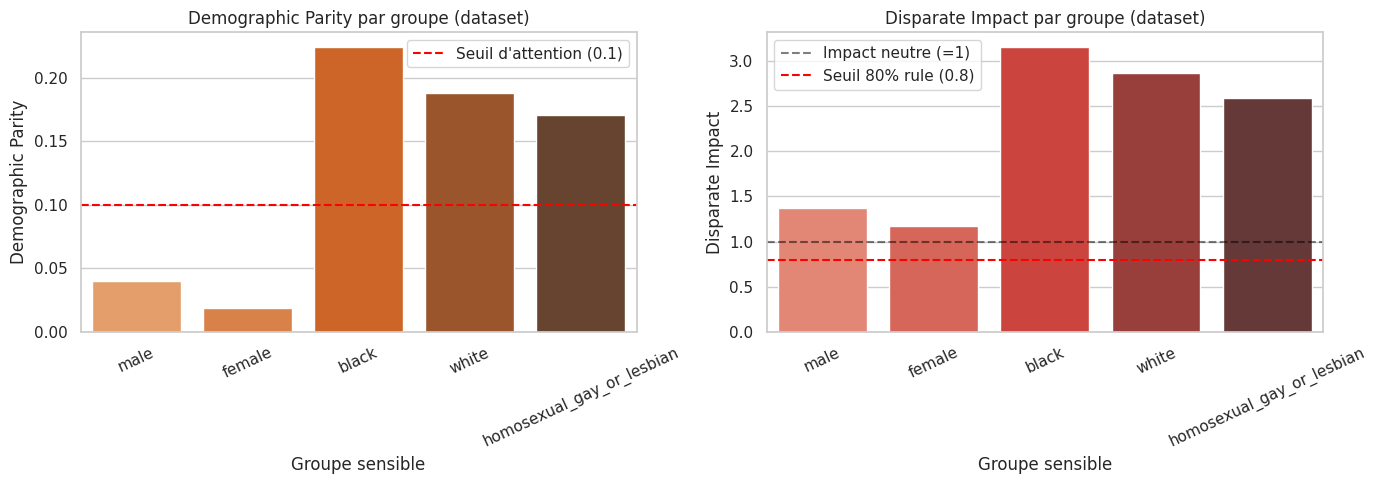

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=fairness_data_df, x='Groupe sensible', y='Demographic Parity', ax=axes[0], palette='Oranges_d')
axes[0].set_title('Demographic Parity par groupe (dataset)')
axes[0].axhline(0.1, color='red', linestyle='--', label='Seuil d\'attention (0.1)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=fairness_data_df, x='Groupe sensible', y='Disparate Impact', ax=axes[1], palette='Reds_d')
axes[1].set_title('Disparate Impact par groupe (dataset)')
axes[1].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Impact neutre (=1)')
axes[1].axhline(0.8, color='red', linestyle='--', label='Seuil 80% rule (0.8)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('fig_fairness_dataset.png', bbox_inches='tight')
plt.show()


Le **Demographic Parity** mesure l'écart absolu de taux de toxicité entre les commentaires mentionnant un groupe et ceux ne le mentionnant pas. Le **Disparate Impact** en mesure le ratio multiplicatif (valeur neutre = 1 ; seuil d'alerte conventionnel = 1,25, règle des 80 %).

Les résultats sont nets. Le groupe `black` présente un DP de 0,224 et un DI de **3,16** — les commentaires le mentionnant ont plus de 3 fois plus de chances d'être toxiques que les autres. Le groupe `white` (DI = 2,86) et `homosexual_gay_or_lesbian` (DI = 2,59) suivent le même schéma, tous largement au-dessus du seuil d'alerte de 1,25.

À l'opposé, les groupes de genre présentent des disparités bien plus faibles : DP = 0,019 et DI = 1,17 pour `female`, DP = 0,040 et DI = 1,37 pour `male`. Ces valeurs sont significatives mais d'un ordre de grandeur différent.

Ces chiffres documentent un **biais structurel dans les données** : les communautés raciales et sexuelles marginalisées sont davantage ciblées par des discours haineux dans ce corpus. Un modèle entraîné sans précaution reproduira et amplifiera ces inégalités.

### 5.2 Fairness du modèle

In [ ]:
def compute_group_metrics(df_test_sub, y_true, y_pred, group_col_bin):
    """Calcule accuracy, FPR, FNR pour chaque sous-groupe."""
    results = []
    for group_val, group_label in [(1, f'{group_col_bin.replace("_bin","")}=1'),
                                    (0, f'{group_col_bin.replace("_bin","")}=0')]:
        mask = df_test_sub[group_col_bin] == group_val
        if mask.sum() < 5:
            continue
        yt = y_true[mask.values]
        yp = y_pred[mask.values]

        tn = ((yt == 0) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        tp = ((yt == 1) & (yp == 1)).sum()

        acc = (tp + tn) / len(yt) if len(yt) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        results.append({
            'Groupe': group_label,
            'N': len(yt),
            'Accuracy': round(acc, 4),
            'FPR': round(fpr, 4),
            'FNR': round(fnr, 4),
        })
    return results

# Récupérer les colonnes binaires pour le test set
for col in SENSITIVE_COLS:
    df_test[col + '_bin'] = (df_test[col] >= THRESHOLD_DEMO).astype(int)

all_metrics = []
for col in SENSITIVE_COLS:
    bin_col = col + '_bin'
    metrics = compute_group_metrics(df_test, y_test, y_pred_best, bin_col)
    all_metrics.extend(metrics)

metrics_df = pd.DataFrame(all_metrics)
print('=== Fairness du MODÈLE (sur le test set) ===')
display(metrics_df)

=== Fairness du MODÈLE (sur le test set) ===


,Groupe,N,Accuracy,FPR,FNR
0,male=1,660,0.8136,0.1581,0.3505
1,male=0,5340,0.8712,0.1069,0.3102
2,female=1,775,0.8155,0.1580,0.3558
3,female=0,5225,0.8722,0.1057,0.3088
4,black=1,207,0.5845,0.5442,0.1000
5,black=0,5793,0.8748,0.1000,0.3371
6,white=1,351,0.5954,0.4980,0.1562
7,white=0,5649,0.8816,0.0929,0.3426
8,homosexual_gay_or_lesbian=1,151,0.6689,0.3679,0.2444
9,homosexual_gay_or_lesbian=0,5849,0.8699,0.1071,0.3211


In [ ]:
# Calcul Equalized Odds difference (FPR et FNR entre groupe=1 et groupe=0)
eo_diff_rows = []
for col in SENSITIVE_COLS:
    sub = metrics_df[metrics_df['Groupe'].str.startswith(col)]
    if len(sub) == 2:
        g1 = sub[sub['Groupe'].str.endswith('=1')].iloc[0]
        g0 = sub[sub['Groupe'].str.endswith('=0')].iloc[0]
        eo_diff_rows.append({
            'Groupe': col,
            'ΔAccuracy': round(abs(g1['Accuracy'] - g0['Accuracy']), 4),
            'ΔFPR': round(abs(g1['FPR'] - g0['FPR']), 4),
            'ΔFNR': round(abs(g1['FNR'] - g0['FNR']), 4),
        })

eo_df = pd.DataFrame(eo_diff_rows)
print('=== Equalized Odds Difference par groupe ===')
display(eo_df)

=== Equalized Odds Difference par groupe ===


,Groupe,ΔAccuracy,ΔFPR,ΔFNR
0,male,0.0576,0.0512,0.0403
1,female,0.0567,0.0523,0.0470
2,black,0.2903,0.4442,0.2371
3,white,0.2862,0.4051,0.1864
4,homosexual_gay_or_lesbian,0.2010,0.2608,0.0767


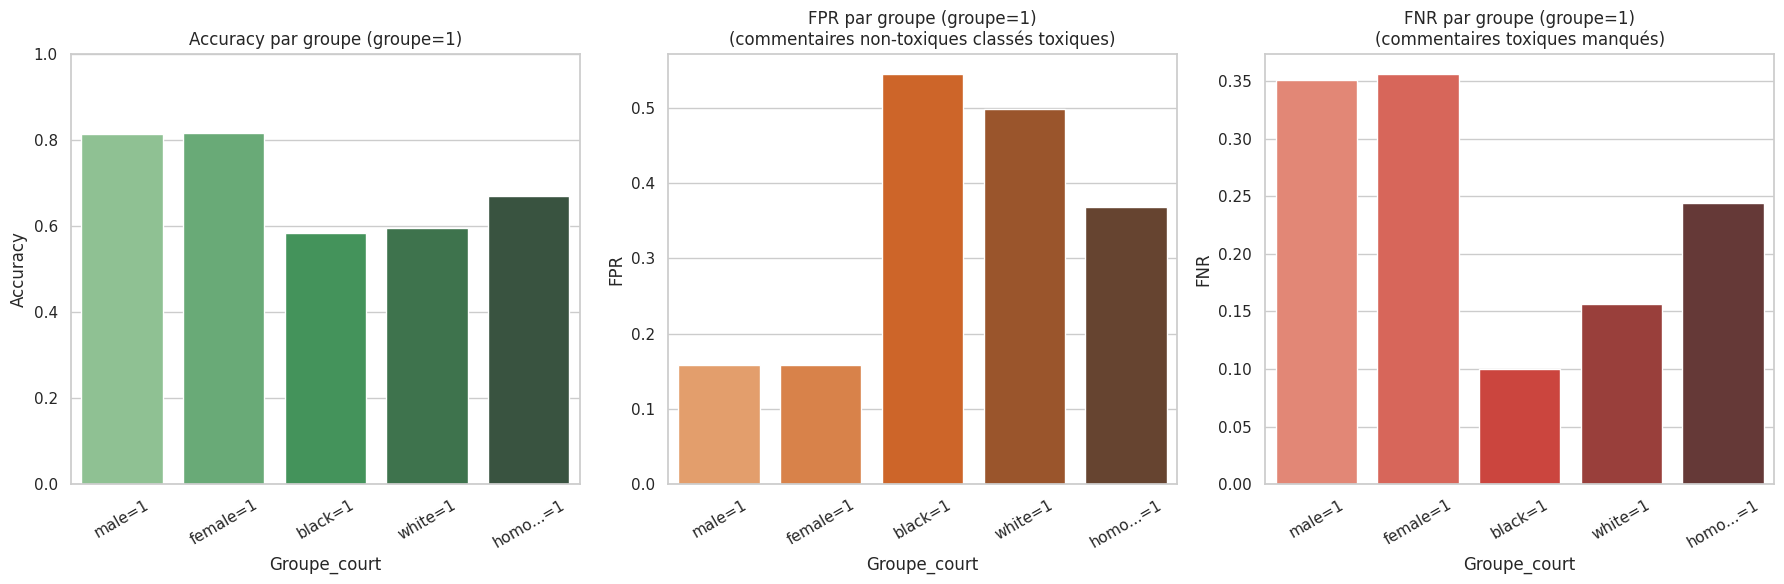

In [ ]:
# Visualisation — FPR et FNR par groupe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Filtrer groupes "=1" seulement pour comparaison inter-groupes
metrics_g1 = metrics_df[metrics_df['Groupe'].str.endswith('=1')].copy()
metrics_g1['Groupe_court'] = metrics_g1['Groupe'].str.replace('_bin=1', '').str.replace('homosexual_gay_or_lesbian', 'homo...')

sns.barplot(data=metrics_g1, x='Groupe_court', y='Accuracy', ax=axes[0], palette='Greens_d')
axes[0].set_title('Accuracy par groupe (groupe=1)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1)

sns.barplot(data=metrics_g1, x='Groupe_court', y='FPR', ax=axes[1], palette='Oranges_d')
axes[1].set_title('FPR par groupe (groupe=1)\n(commentaires non-toxiques classés toxiques)')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=metrics_g1, x='Groupe_court', y='FNR', ax=axes[2], palette='Reds_d')
axes[2].set_title('FNR par groupe (groupe=1)\n(commentaires toxiques manqués)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_fairness_model.png', bbox_inches='tight')
plt.show()


**Biais dans les données :**

L'analyse du dataset révèle des disparités profondes et cohérentes. Les commentaires mentionnant `black` sont toxiques à 32,9 % contre 10,4 % pour les autres (Disparate Impact = 3,16) ; `white` à 28,9 % (DI = 2,86) ; `homosexual_gay_or_lesbian` à 27,9 % (DI = 2,59). Ces écarts ne reflètent pas une toxicité intrinsèque de ces groupes, mais le fait qu'ils sont des cibles récurrentes de discours haineux sur les plateformes qui ont produit ce dataset. Le biais est dans les données elles-mêmes, avant même l'étape d'entraînement.

**Biais dans le modèle :**

Le modèle hérite et amplifie ces disparités de façon alarmante. Pour les commentaires mentionnant `black` (N = 207 dans le test set), le FPR atteint **54,4 %** : plus d'un commentaire non-toxique sur deux mentionnant ce groupe est classé à tort comme toxique. Pour `white`, le FPR est de 49,8 % ; pour `homosexual_gay_or_lesbian`, 36,8 %. L'accuracy chute à 58-67 % pour ces groupes, contre 87-88 % pour les commentaires n'y faisant pas référence. La différence d'Equalized Odds est de 0,444 pour `black` et 0,405 pour `white` — des valeurs très élevées qui confirment une inéquité sévère.

Les groupes de genre (`male`, `female`) présentent des disparités plus modérées (Delta FPR ~ 0,05, Equalized Odds ~ 0,05) mais non nulles.

**Risques de déploiement :**

Déployer ce modèle dans un système de modération automatique produirait des effets discriminatoires documentables et légalement problématiques. Un commentaire non-toxique qui mentionne simplement la communauté noire ou homosexuelle a plus de 50 % de chances d'être supprimé à tort. Ce mécanisme pénalise précisément les voix des communautés les plus ciblées par les discours haineux — un paradoxe profond. L'effet de rétroaction (les données de modération biaisées alimentent les futures versions du modèle) aggraverait ces disparités dans le temps.

**Pistes d'amélioration :** débiaisage ciblé des données d'entraînement (rééquilibrage par groupe), contraintes d'équité dans l'optimisation (FairLearn, Adversarial Debiasing), fine-tuning de modèles contextuels de type BERT pour dépasser la représentation sac-de-mots et capturer le sens dans son contexte, et audit systématique des métriques de fairness par sous-groupe en production.